In [2]:
import os
import sys
import tqdm
import utils
import blosc2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
from scipy.ndimage import gaussian_filter1d
import preprocess_data as ppd
import lstm_module as lstm 
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients
import pandas as pd
import importlib
import process_attribution
from process_session import session as ss
import process_probe as pp
import process_attribution as pa
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def reload_everthing():
    importlib.reload(pa)
    importlib.reload(ppd)
    importlib.reload(pp)
    importlib.reload(lstm)
    importlib.reload(utils)
    importlib.reload(process_attribution)

cuda


In [3]:
session_id = 1044385384
session_obj = ss(session_id)
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

probe_obj = pp.probe(session_obj)
lfp_obj = ppd.pre_process_lfp(probe_obj.lfp, 1250)
lfp_obj.filter_lfp(probe_obj.bands)

c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  return func(args[0], **pargs)
100%|██████████| 741/741 [00:51<00:00, 14.28it/s]
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  return func(args[0], **pargs)
100%|██████████| 8/8 [02:50<00:00, 21.26s/it]


In [100]:
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 32
num_layers = 1
seqlength = 1000
num_epochs = 15
X_train, y_train, X_val, y_val, X_test, y_test = ppd.generate_training_data(lfp_obj, spikes_obj, seqlength)

In [ ]:
models, lossesAll_train, lossesAll_val = utils.train_models(probe_obj, input_size, hidden_size, num_layers, seqlength, device, num_epochs, X_train, y_train, X_val, y_val, 8)
# save the models 
# output_dir = Path('E:/vbn_s3_cache')
# utils.save_models(models, output_dir, session_id)

100%|██████████| 20/20 [21:50<00:00, 65.54s/it]


In [ ]:
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 32
num_layers = 1
num_epochs = 15
seq_lengths = np.arange(50,2000,25).astype(int)
loss_train = np.zeros(len(seq_lengths))
loss_val = np.zeros(len(seq_lengths))
r2_scores = np.zeros(len(seq_lengths))
for i, seqlength in enumerate(tqdm.tqdm(seq_lengths)):
    X_train, y_train, X_val, y_val, X_test, y_test = ppd.generate_training_data(lfp_obj, spikes_obj, seqlength)
    X_train = torch.reshape(X_train, (X_train.shape[0]*X_train.shape[1], X_train.shape[2]))
    y_train = torch.reshape(y_train, (y_train.shape[0]*y_train.shape[1],y_train.shape[2],y_train.shape[3]))
    model, lossesAll_train = utils.train_models(probe_obj, input_size, hidden_size, num_layers, seqlength, device, num_epochs, X_train, y_train)
    loss_train[i] = lossesAll_train[-1]
    # loss_val[i] = lossesAll_val[-1]
    X_test = torch.reshape(X_test, (X_test.shape[0]*X_test.shape[1], X_test.shape[2]))
    y_test = torch.reshape(y_test, (y_test.shape[0]*y_test.shape[1],y_test.shape[2],y_test.shape[3]))
    y_Hat = model.evaluate(X_test)
    r2_scores[i] = r2_score(y_test[:,4,0].detach().cpu().numpy(), y_Hat)

100%|██████████| 78/78 [03:58<00:00,  3.06s/it]


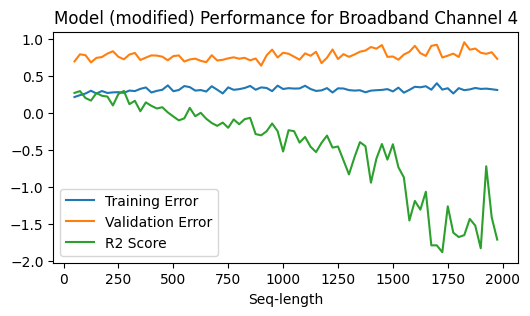

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(seq_lengths, loss_train, label='Training Error')
plt.plot(seq_lengths, loss_val, label='Validation Error')
plt.plot(seq_lengths, r2_scores, label='R2 Score')
plt.xlabel("Seq-length")
plt.title("Model (modified) Performance for Broadband Channel 4")
plt.legend()

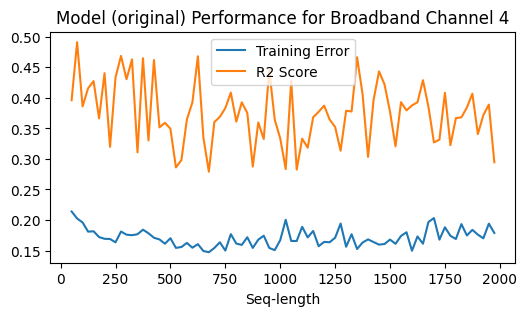

In [139]:
plt.figure(figsize=(6,3))
plt.plot(seq_lengths, loss_train, label='Training Error')
# plt.plot(seq_lengths, loss_val, label='Validation Error')
plt.plot(seq_lengths, r2_scores, label='R2 Score')
plt.xlabel("Seq-length")
plt.title("Model (original) Performance for Broadband Channel 4")
plt.legend()


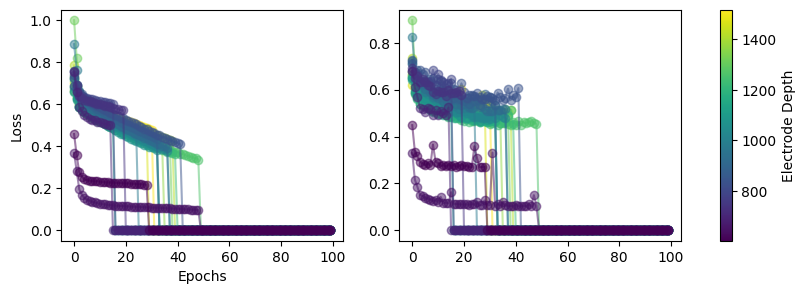

In [81]:
# plot losses for the broadband model for all channels color coded by depth
import matplotlib.cm as cm
import matplotlib.colors as mcolors
num_channels = len(probe_obj.chans)
fig,ax = plt.subplots(1,2,figsize=(10,3))

norm = mcolors.Normalize(vmin=probe_obj.chans['dorsal_ventral_ccf_coordinate'].min(), vmax=probe_obj.chans['dorsal_ventral_ccf_coordinate'].max())
cmap = cm.viridis

for chani in range(num_channels):
    color = cmap(norm(probe_obj.chans['dorsal_ventral_ccf_coordinate'].iloc[chani]))
    ax[0].plot(lossesAll_train[chani, :, 1], 'o-', alpha=0.5, color=color)
    ax[1].plot(lossesAll_val[chani, :, 1], 'o-', alpha=0.5, color=color)

ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
# ax.set_title('Model loss for broadband model')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Electrode Depth')

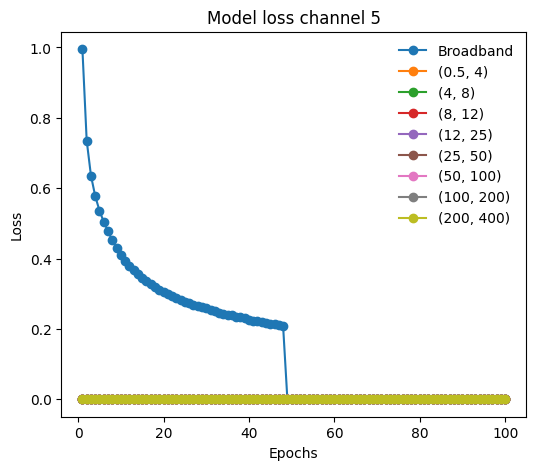

In [27]:
# plot the losses of chl5 for all bands
fig,ax = plt.subplots(1,1,figsize=(6,5))

ax.plot(list(range(1,num_epochs+1)), lossesAll_train[5,:,:],'o-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss channel 5')
# add legend without boxing
ax.legend(['Broadband'] + [str(probe_obj.bands[i]) for i in range(len(probe_obj.bands))], frameon=False, loc='upper right')



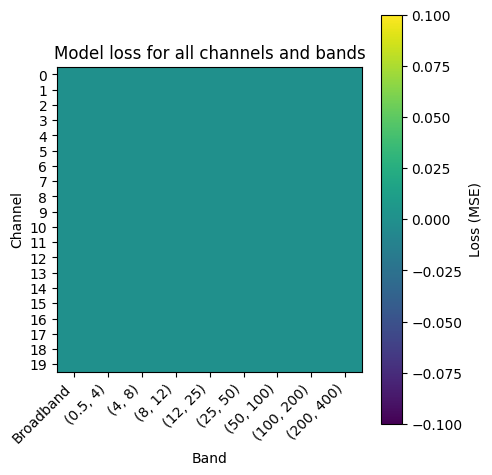

In [97]:
# plot a matrix of losses for the last epoch for all channels and bands
fig,ax = plt.subplots(1,1,figsize=(5,5))
bands = probe_obj.bands
# make the plot square 
cax = ax.imshow(lossesAll_train[:,-1,:], aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model loss for all channels and bands')
ax.set_yticks(range(num_channels))
# ax.set_yticklabels(session_obj.channels.dorsal_ventral_ccf_coordinate, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('Loss (MSE)')
plt.tight_layout()


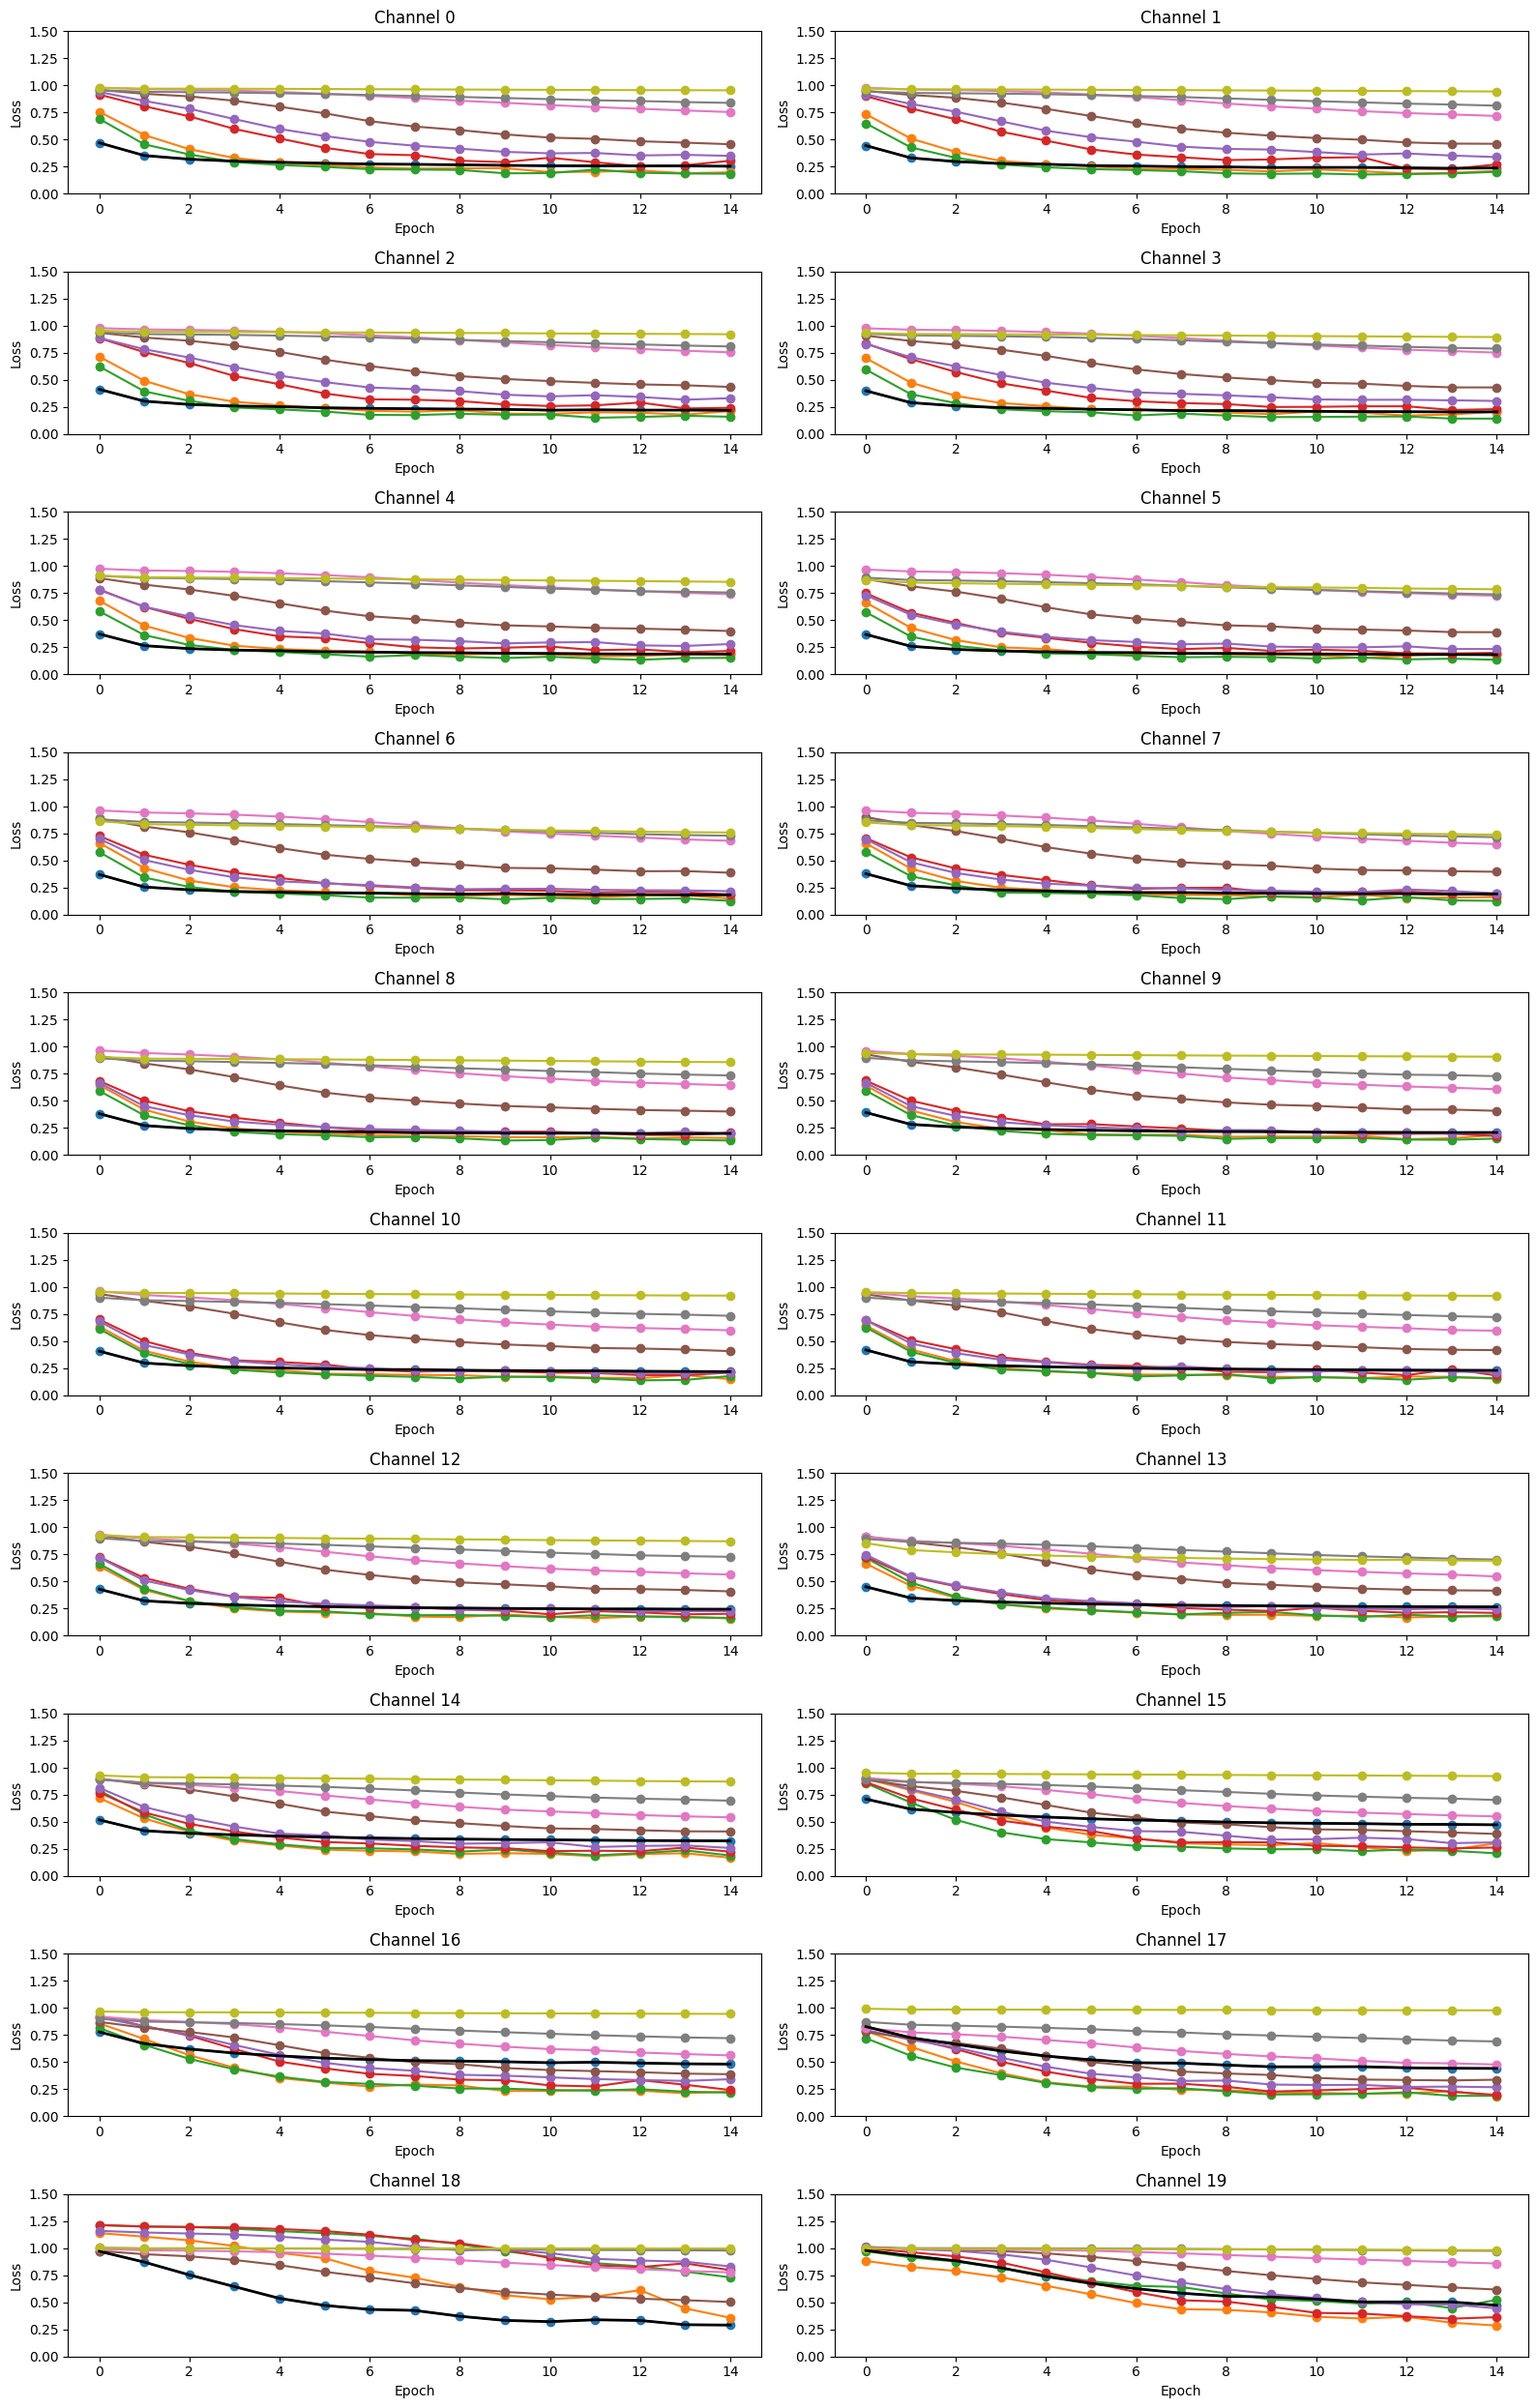

In [17]:
# for each channel, plot the loss for all bands
fig, ax = plt.subplots(int(np.ceil(num_channels/2)),2, figsize=(16, 25))
for chani in range(num_channels):
    ax.flat[chani].plot(lossesAll[chani,:,:,], 'o-')
    ax.flat[chani].plot(lossesAll[chani,:,0], 'k', label='LFP', linewidth=2)
    ax.flat[chani].set_title('Channel ' + str(chani))
    ax.flat[chani].set_xlabel('Epoch')
    ax.flat[chani].set_ylabel('Loss')
    ax.flat[chani].set_ylim([0, 1.5])
    # add space between subplots
    plt.tight_layout()


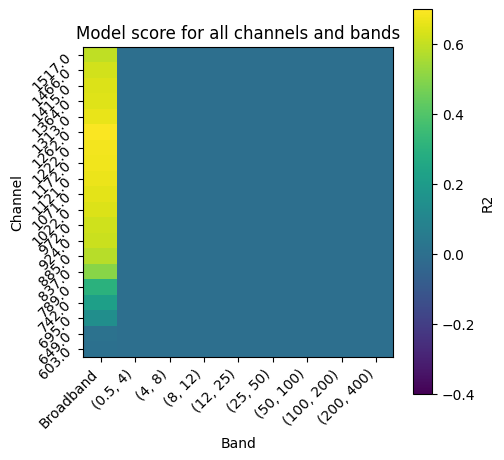

In [ ]:
###
# compute model scores for all channels and bands for the training data and the test data
scoresTrain = np.zeros((num_channels, len(bands)+1))
scoresTest = np.zeros((num_channels, len(bands)+1))

for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        if bandi != 0: continue
        yHat_train = models[chani, bandi].evaluate(X_train);
        yHat_test  = models[chani, bandi].evaluate(X_test)
        r2_train = r2_score(y_train[:, :, chani, bandi].cpu().detach().numpy(), yHat_train)
        r2_test  = r2_score(y_test[:, :, chani, bandi].cpu().detach().numpy(), yHat_test)
        scoresTrain[chani, bandi] = r2_train
        scoresTest[chani, bandi] = r2_test
        # break
        
# plot as a matrix
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square
cax = ax.imshow(scoresTest, aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model score for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(probe_obj.chans['dorsal_ventral_ccf_coordinate'], rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('R2')
cax.set_clim(-.4, .7);

In [7]:
import numpy as np
a = np.array([1,1,2,3,4])
target = np.array([2,3])
np.where(a==target)

C:\Users\Marisol\AppData\Local\Temp\ipykernel_1684\3913786345.py:4: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  np.where(a==target)


(array([], dtype=int64),)

In [45]:
spikes_obj.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()
cache=VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir='F:/vbn_s3_cache')
session = cache.get_ecephys_session(session_id)
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
chan = session.get_channels()
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
num_channels = len(visp_df)
lfp_slice = probeC.sel(time=slice(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1]), channel=visp_df.index)

lfp_obj = ppd.pre_process_lfp(lfp_slice.values, 1250)
lfp_obj.filter_lfp(bands)

# resample data from 1250 Hz to 250 Hz to match the spike data
data = lfp_obj.lfpMat[::5,:,:]
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:,:]

100%|██████████| 741/741 [00:04<00:00, 183.11it/s]
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  return func(args[0], **pargs)
100%|██████████| 8/8 [00:06<00:00,  1.25it/s]

(72251, 20, 9)
(72250, 741)


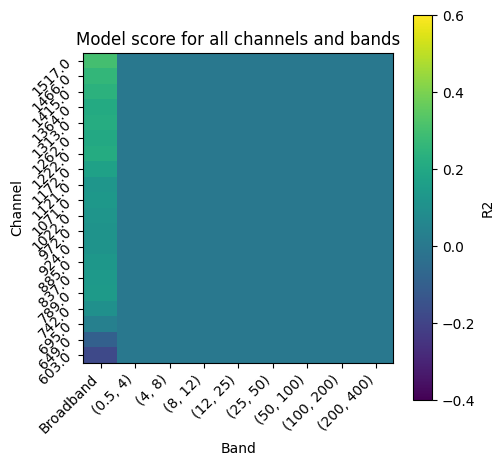

In [62]:
X_spont = torch.tensor(spikes_obj.spkMat).float().to(device)
y_spont = torch.tensor(data).float().to(device)

# compute model scores for all channels and bands for the training data and the test data
scoresSpont = np.zeros((num_channels, len(bands)+1))
length = 200
n_trials = X_spont.shape[0]//length
X_spont_reshaped = torch.reshape(X_spont[:n_trials*length,:], (n_trials, length, X_spont.shape[1]))
y_spont_reshaped = torch.reshape(y_spont[:n_trials*length,:,:], (n_trials, length, y_spont.shape[1], y_spont.shape[2]))

# X_spont = torch.reshape(X_spont, (1, X_spont.shape[0], X_spont.shape[1]))
for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        models[chani, bandi].model.to(device)
        yHat = models[chani, bandi].evaluate(X_spont_reshaped)
        r2  = r2_score(y_spont_reshaped[:, :,chani, bandi].cpu().detach().numpy(), yHat)
        scoresSpont[chani, bandi] = r2
        break
      
        
# plot as a matrix
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square
cax = ax.imshow(scoresSpont, aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model score for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(visp_df.dorsal_ventral_ccf_coordinate, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('R2')
cax.set_clim(-.4, .6)

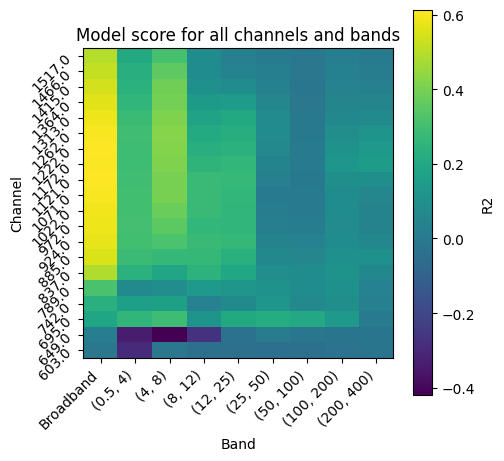

In [ ]:
###
# compute model scores for all channels and bands for the training data and the test data
scoresTrain = np.zeros((num_channels, len(bands)+1))
scoresTest = np.zeros((num_channels, len(bands)+1))

for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        yHat_train = models[chani, bandi].evaluate(X_train);
        yHat_test  = models[chani, bandi].evaluate(X_test)
        r2_train = r2_score(y_train[:, :, chani, bandi].cpu().detach().numpy(), yHat_train)
        r2_test  = r2_score(y_test[:, :, chani, bandi].cpu().detach().numpy(), yHat_test)
        scoresTrain[chani, bandi] = r2_train
        scoresTest[chani, bandi] = r2_test
      
        
# plot as a matrix
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square
cax = ax.imshow(scoresTest, aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model score for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(probe_obj.chans['dorsal_ventral_ccf_coordinate'], rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('R2');


ValueError: x and y must have same first dimension, but have shapes (1250,) and (180, 9)

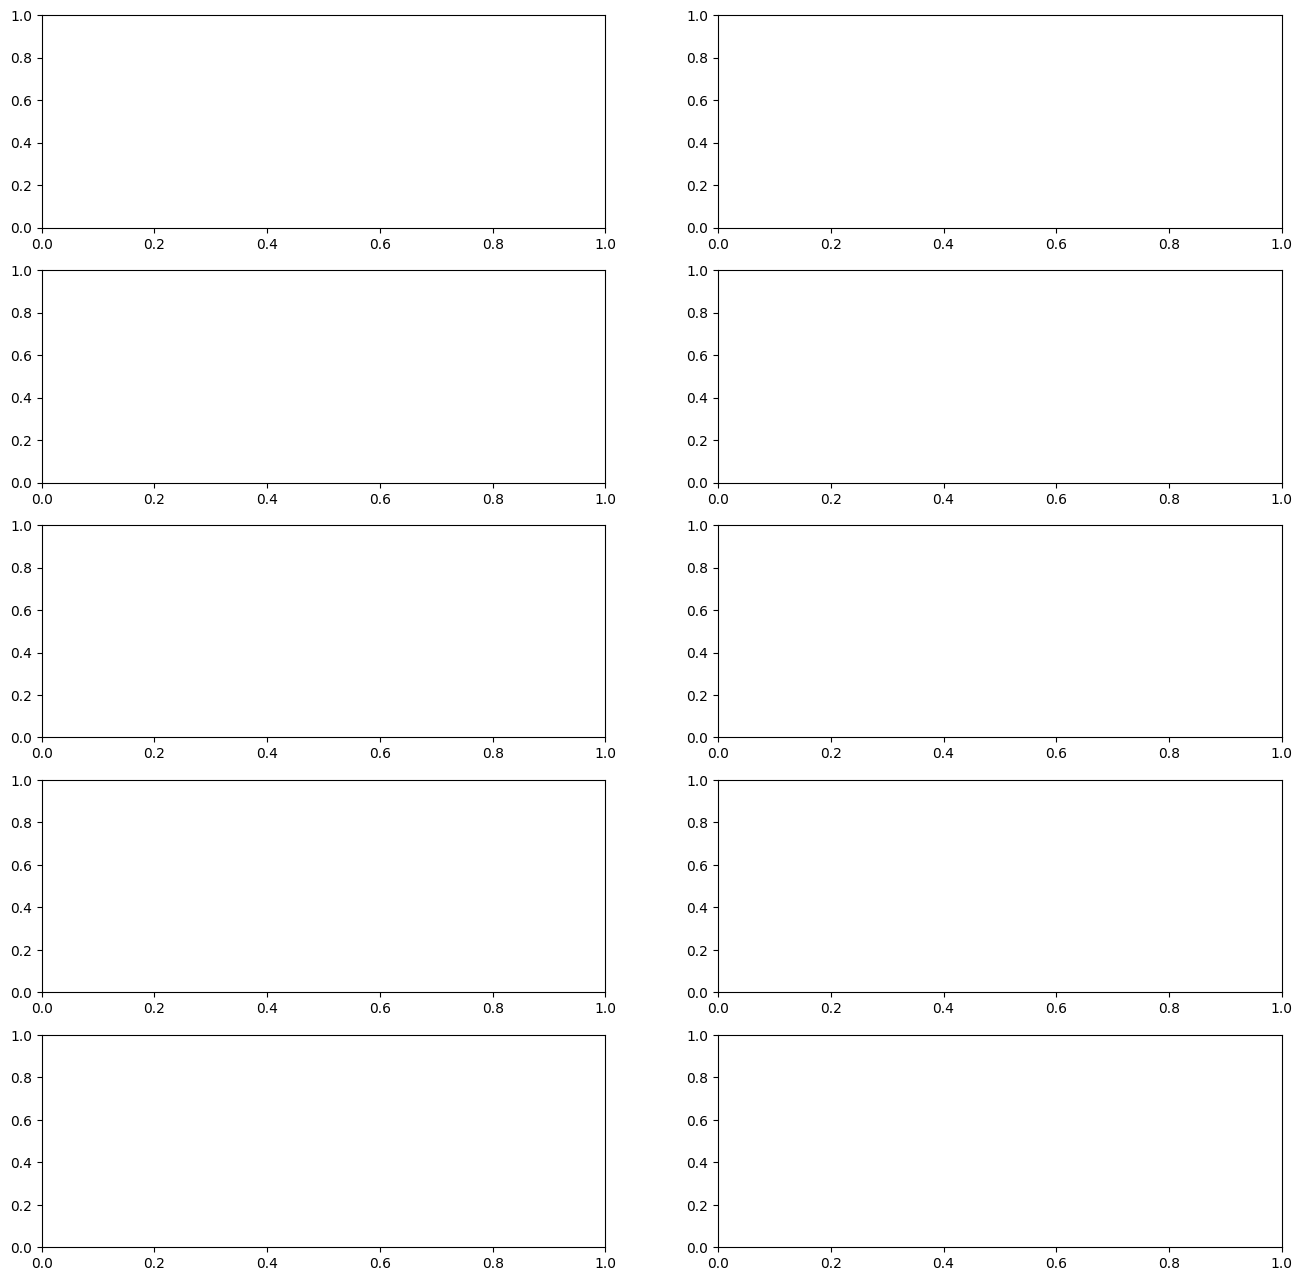

In [ ]:
###
# plot the data and prediction for all bands from a single channel
chani = 5
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2, figsize=(16, 16))
bin_size = 0.004
for bandi in range(len(bands)+1):
    yHat_test = models[chani, bandi].evaluate(X_test)
    ax.flat[bandi].plot(np.linspace(0,5,int(5/bin_size)), y_test.cpu().detach().numpy()[:int(5/bin_size), chani, bandi],'k',label='LFP')
    ax.flat[bandi].plot(np.linspace(0,5,int(5/bin_size)), yHat_test[:int(5/bin_size)],'r',label='LSTM')
    if bandi == 0:
        ax.flat[bandi].set_title('Channel ' + str(chani) + ' Broadband')
    else:
        ax.flat[bandi].set_title('Channel ' + str(chani) + ' Band: ' + str(bands[bandi-1]) + ' Hz')
    
fig.delaxes(ax.flat[-1])

In [16]:
importlib.reload(utils)
importlib.reload(pa)

<module 'process_attribution' from 'e:\\jerry\\github_repo\\spikes2lfp\\process_attribution.py'>

In [4]:
# check if a variable models exists otherwise load it from the saved models
output_dir = Path(r"Z:\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022")

args = [input_size, hidden_size, num_layers, seqlength, device]
models = utils.load_models(output_dir, session_id, probe_obj, args)

In [5]:
os.environ["OMP_NUM_THREADS"] = "1"

In [6]:
output_dir = Path(r'F:\vbn_s3_cache')
dur = 720
bin_size = 0.004
pa.divide_task_for_attr(models, session_id, output_dir, spikes_obj, bin_size, probe_obj, dur)

In [ ]:
dur = 720
X_attr = spikes_obj.spkMat[:int(dur/bin_size), :] # first 720 seconds of data
X_attr = torch.tensor(X_attr).float()

# for each channel and band, run the attribution algorithm
for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        sys.stdout.write('running atribution analysis on chan ' + str(chani) + ' band ' + str(bandi) + '.\n')
        mdl = models[chani, bandi].model.train().to('cpu')
        
        integrated_gradients = IntegratedGradients(mdl)
        filename = output_dir / 'models' / str(session_id) / f'attribution_scores_chan{chani}_band{bandi}.npy' 
        attributions = []
        for i in tqdm.tqdm(range(0,X_attr.shape[0],100)):
            attributions.append(integrated_gradients.attribute(X_attr[i:i+100,:].contiguous(),  target=0,  n_steps=50))
        attributions = torch.cat(attributions)
        attributions = attributions.cpu().detach().numpy().astype('float32')
        np.save(filename, attributions, allow_pickle=True)


running atribution analysis on chan 0 band 0.


100%|██████████| 1800/1800 [05:35<00:00,  5.36it/s]


running atribution analysis on chan 0 band 1.


100%|██████████| 1800/1800 [05:52<00:00,  5.11it/s]


running atribution analysis on chan 0 band 2.


...

100%|██████████| 1800/1800 [05:24<00:00,  5.54it/s]


running atribution analysis on chan 19 band 7.


100%|██████████| 1800/1800 [05:24<00:00,  5.54it/s]


running atribution analysis on chan 19 band 8.


100%|██████████| 1800/1800 [05:25<00:00,  5.53it/s]


In [177]:
# for each channel and band, load the attribution and calculate the mean attribution for each unit
attributions = np.zeros((num_channels, len(bands)+1 , X_attr.shape[1]))
for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        filename = output_dir / 'models' / str(session_id) / f'attribution_scores_chan{chani}_band{bandi}.npy'
        attributions[chani, bandi,:] = np.mean(np.load(filename), axis=0)


In [242]:
# find the index of units in the units dataframe that are also in df dataframe
locs2save = units.index.isin(df.index)

# for each area, calculate the mean attribution across all channels and bands
areas = sorted(df['location'].unique())
attributions_areas = np.zeros((len(areas), len(bands)+1, num_channels))
for areai, area in enumerate(areas):
    ind = ([units['structure_acronym'] == area])[0] & locs2save
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            attributions_areas[areai, bandi, chani] = np.mean(attributions[chani, bandi, ind])

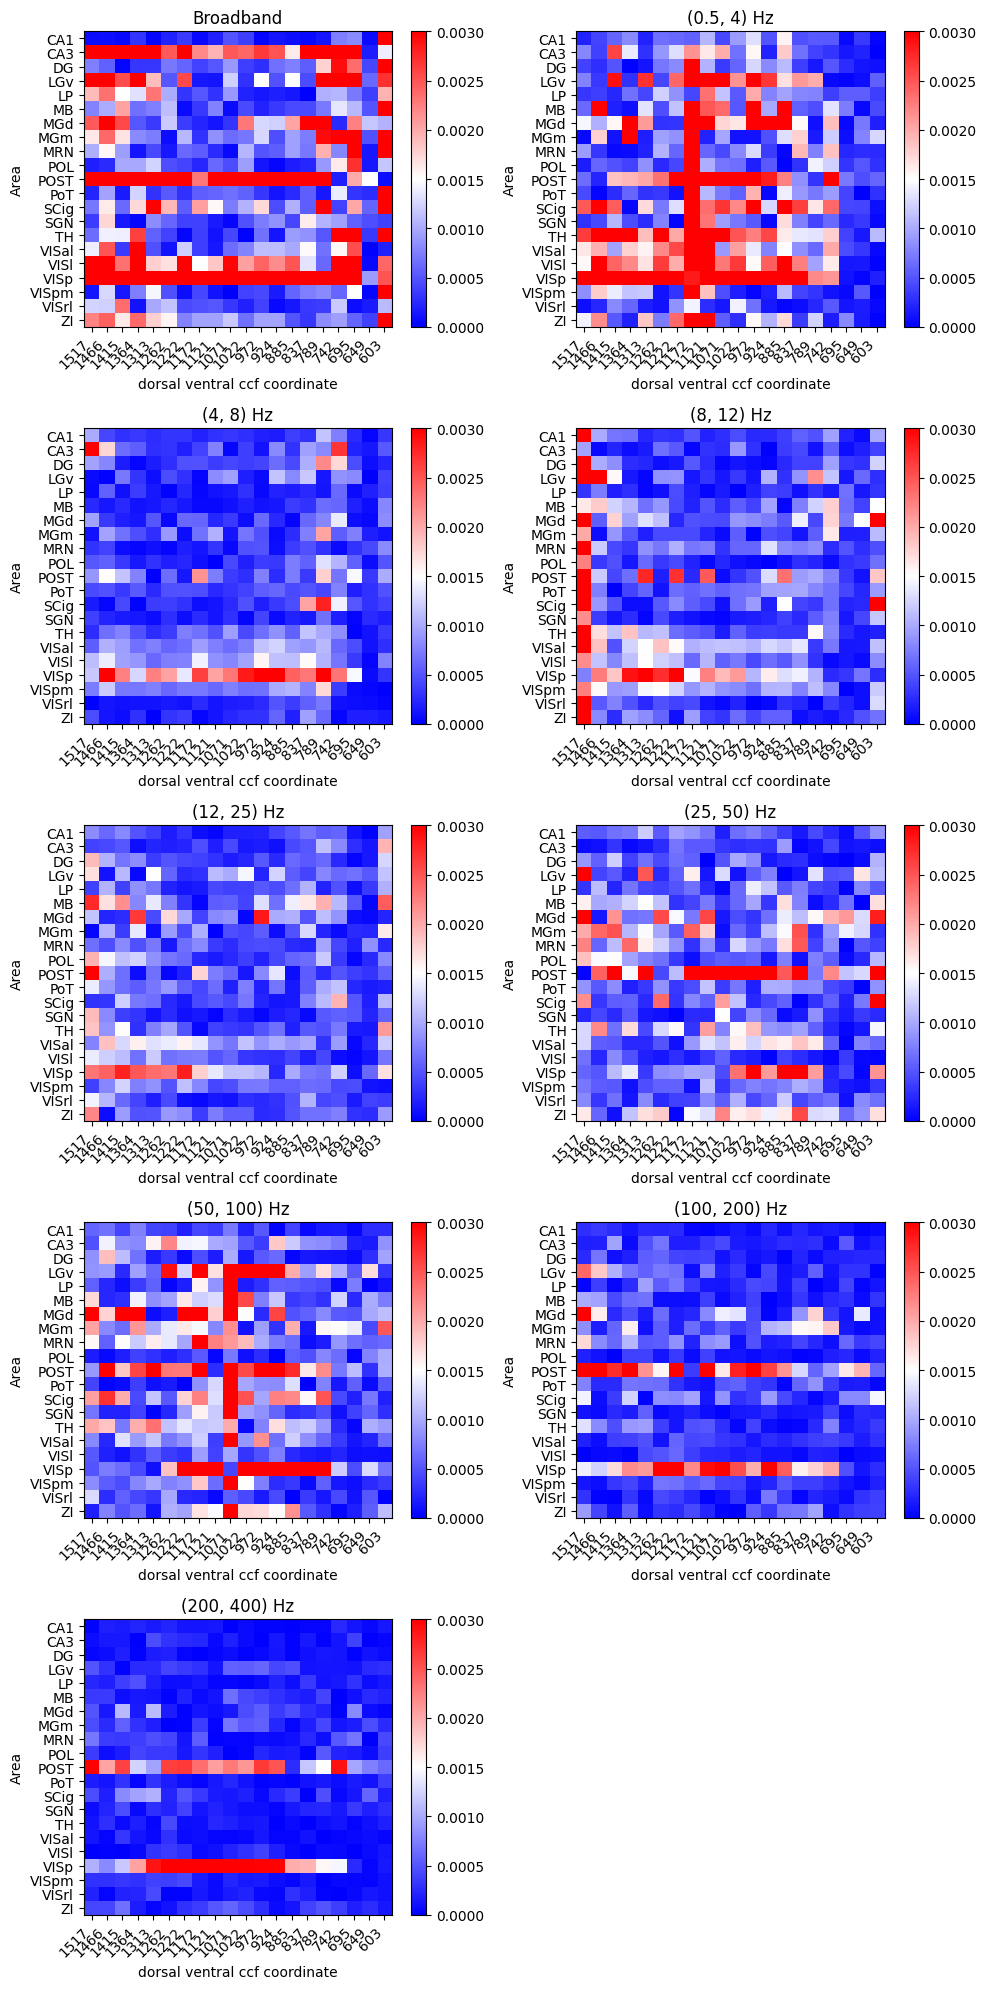

In [236]:
# for each band, plot the mean attribution for each area
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow( np.abs(attributions_areas[:,bandi,:]) , aspect='auto', vmin=0, vmax=0.003, cmap='bwr')
    # set the xticks to be the channel depths
    ax.flat[bandi].set_xticks(range(num_channels))
    ax.flat[bandi].set_xticklabels(visp_df['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45, ha='right')
    ax.flat[bandi].set_xlabel('dorsal ventral ccf coordinate')

    # set the yticks to be the area names
    ax.flat[bandi].set_yticks(range(len(areas)))
    ax.flat[bandi].set_yticklabels(areas)
    ax.flat[bandi].set_ylabel('Area')
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        
    cbar = fig.colorbar(ax.flat[bandi].imshow(np.abs(attributions_areas[:,bandi,:]), aspect='auto', vmin=0, vmax=0.003, cmap='bwr'), ax=ax.flat[bandi])

# tight layout
plt.tight_layout()
fig.delaxes(ax.flat[-1])

In [269]:
# get the mean attribution scores for each cluster_id across all channels and bands
units_df_merged = units.merge(df, how='left', left_on='id', right_index=True)

mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, num_channels))

for clusteri in range(1,6,1):
    for bandi in range(len(bands)+1):
        for chani in range(num_channels):
            ind = (units_df_merged['cluster_id_y'] == clusteri)
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(attributions[chani, bandi, ind])

(0.0, 1.0, 0.0, 1.0)

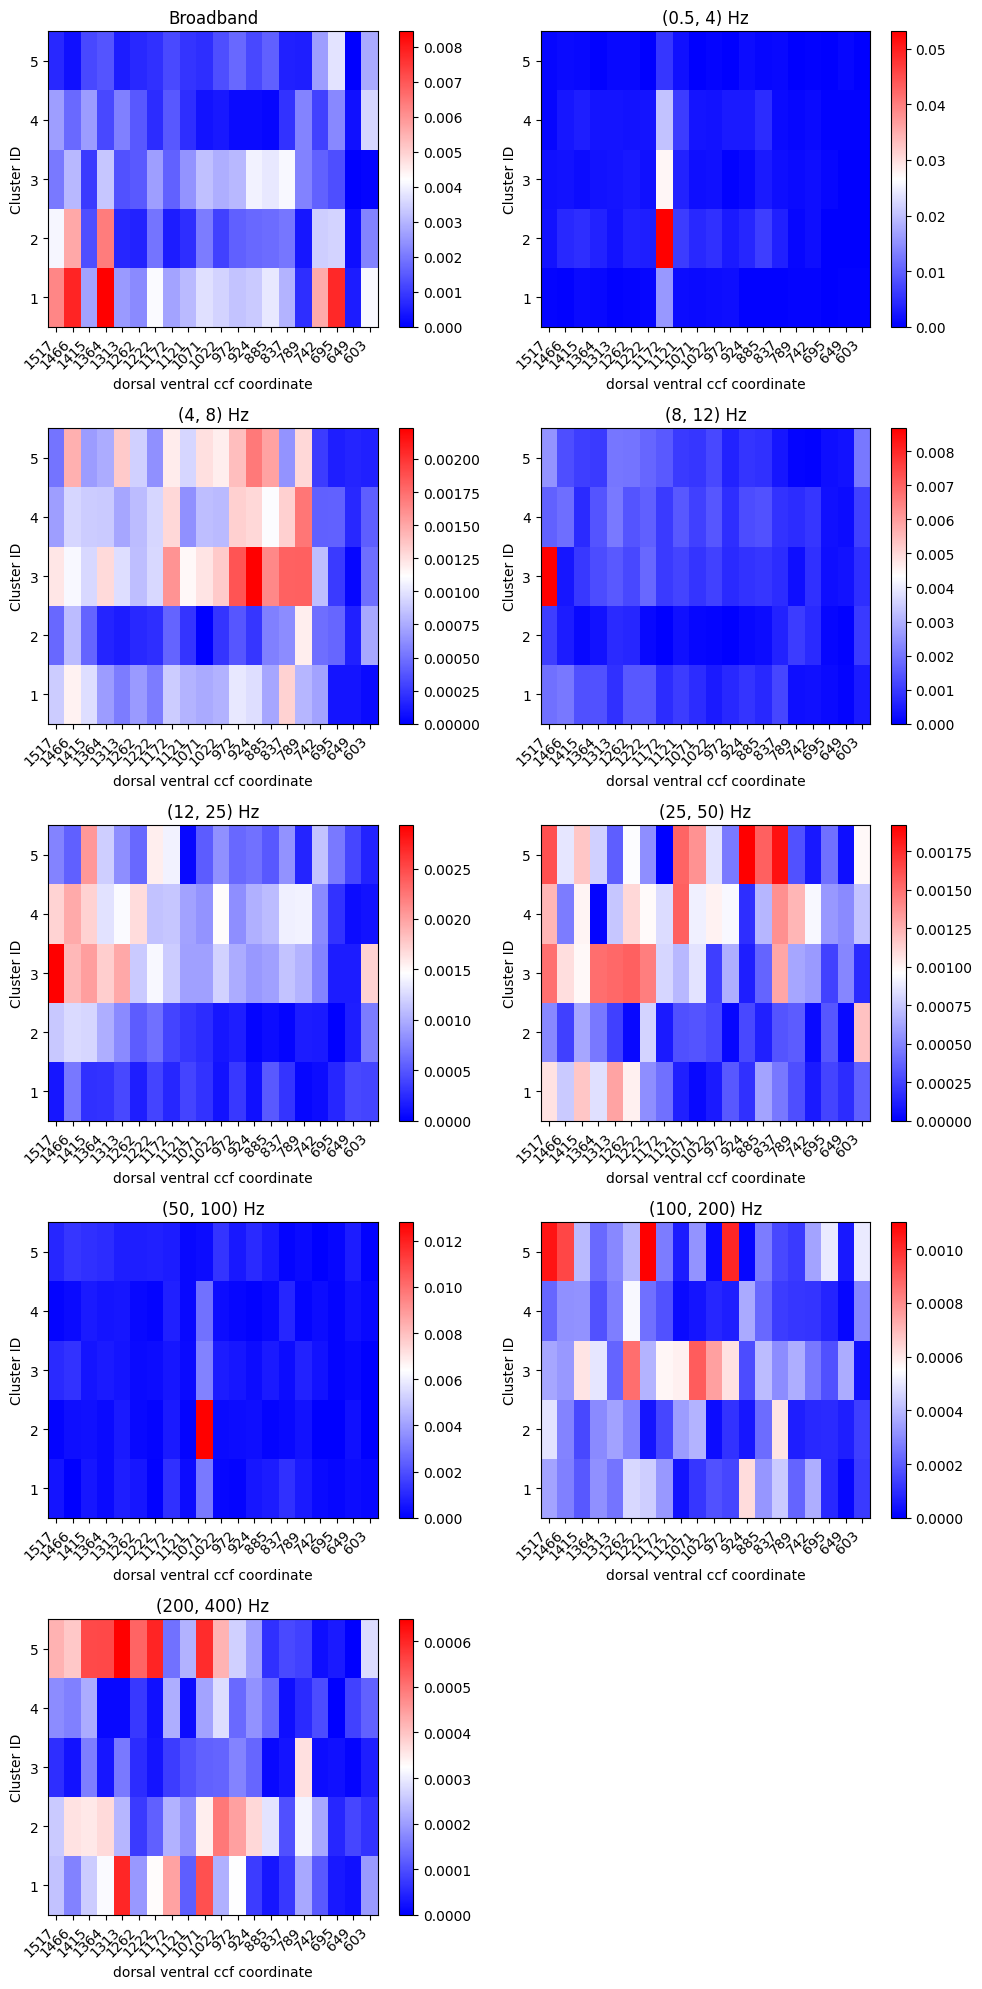

In [278]:
# plot the mean attribution for each band for each cluster and channel
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))

for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow( np.abs(mean_attr_clusters[:,bandi,:]) , aspect='auto',cmap='bwr')
    # set the xticks to be the channel depths
    ax.flat[bandi].set_xticks(range(num_channels))
    ax.flat[bandi].set_xticklabels(visp_df['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45, ha='right')
    ax.flat[bandi].set_xlabel('dorsal ventral ccf coordinate')
    ax.flat[bandi].set_ylim([.5,5.5])
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
    # set the yticks to be the cluster ids
    ax.flat[bandi].set_yticks(range(1,6,1))
    ax.flat[bandi].set_yticklabels(range(1,6,1))
    ax.flat[bandi].set_ylabel('Cluster ID')
    cbar = fig.colorbar(ax.flat[bandi].imshow(np.abs(mean_attr_clusters[:,bandi,:]), aspect='auto', cmap='bwr'), ax=ax.flat[bandi])
    
# tight layout
plt.tight_layout()
ax.flat[-1].axis('off')

In [305]:
# for a selected channel, calculate the correlation between each units' attribution and the firing-rate
dur = 720
X_attr = spikes_obj.spkMat[:int(dur/bin_size), :] # first 720 seconds of data
chani = 5
unit_attr_fr_corr = np.zeros( (locs2save.sum() , len(bands)+1))
X_attr = X_attr[:,locs2save]

for bandi in range(len(bands)+1):
    filename = output_dir / 'models' / str(session_id) / f'attribution_scores_chan{chani}_band{bandi}.npy'
    attributions = np.load(filename)
    attributions = attributions[:,locs2save]
    for uniti in range(locs2save.sum()):
        unit_attr_fr_corr[uniti, bandi] = np.corrcoef(attributions[:,uniti], X_attr[:,uniti])[0,1]

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\numpy\lib\function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [332]:
# get the units locations and sorting index for later plotting
locs = units_df_merged['location'][locs2save].values
sidx = np.argsort(locs)
# find the first and last index of each area
areas = sorted(df['location'].unique())
area_idx = []
for area in areas:
    area_idx.append(np.where(locs[sidx] == area)[0][0])
    
print(area_idx)

[0, 131, 153, 189, 194, 218, 223, 226, 228, 253, 309, 313, 331, 333, 354, 379, 407, 488, 498, 562, 607]


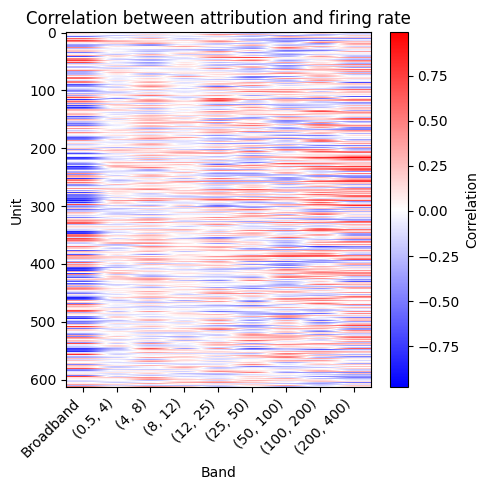

In [331]:
# plot the correlation between the attribution and the firing rate for each unit and band
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.imshow(unit_attr_fr_corr[sidx,:], aspect='auto', cmap='bwr')
ax.set_xlabel('Band')
ax.set_ylabel('Unit')
ax.set_title('Correlation between attribution and firing rate')
# ax.set_yticks(area_idx)
# ax.set_yticklabels(areas, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
cbar = fig.colorbar(ax.imshow(unit_attr_fr_corr, aspect='auto', cmap='bwr'), ax=ax)
cbar.set_label('Correlation')
plt.tight_layout()
plt.show()

In [436]:
# calculate the mean attribution for each unit around the time of the stimulus
stim_st  = behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].values
stim_st = stim_st[stim_st < dur]
stim_st = stim_st[1:]

nbins = int(0.75/bin_size)
t = np.linspace(-0.25, 0.5, nbins)

chani = 10

filename = output_dir / 'models' / str(session_id) / f'attribution_scores_chan{chani}_band{0}.npy'
attributions = np.load(filename)
attributions = attributions[:,locs2save]

mdl = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion,'cpu')
filename = output_dir / 'models' / str(session_id) / f'lstm_model_chan{chani}_band{0}.pt'
mdl.model.load_state_dict(torch.load(filename))
X_attr = spikes_obj.spkMat[:int(dur/bin_size), :] 
X_attr_tensor = torch.tensor(X_attr, dtype=torch.float32)
yHat = mdl.evaluate(X_attr_tensor)

attributions_snippets = np.zeros((len(stim_st), nbins, attributions.shape[1]))
X_attr_snippets = np.zeros((len(stim_st), nbins, X_attr.shape[1]))
lfp_snippets = np.zeros((len(stim_st), nbins))
yHat_snippets = np.zeros((len(stim_st), nbins))

for i in range(len(stim_st)):
    start = np.argmin(np.abs(spikes_obj.timestamps - (stim_st[i]-.25)))
    attributions_snippets[i,:,:] = attributions[start:start+nbins,:]
    X_attr_snippets[i,:,:] = X_attr[start:start+nbins,:]
    lfp_snippets[i,:] = data[start:start+nbins,chani,0]
    yHat_snippets[i,:] = yHat[start:start+nbins]


C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_22964\2058435759.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mdl.model.load_state_dict(torch.load(filename))


(0.0, 1.0, 0.0, 1.0)

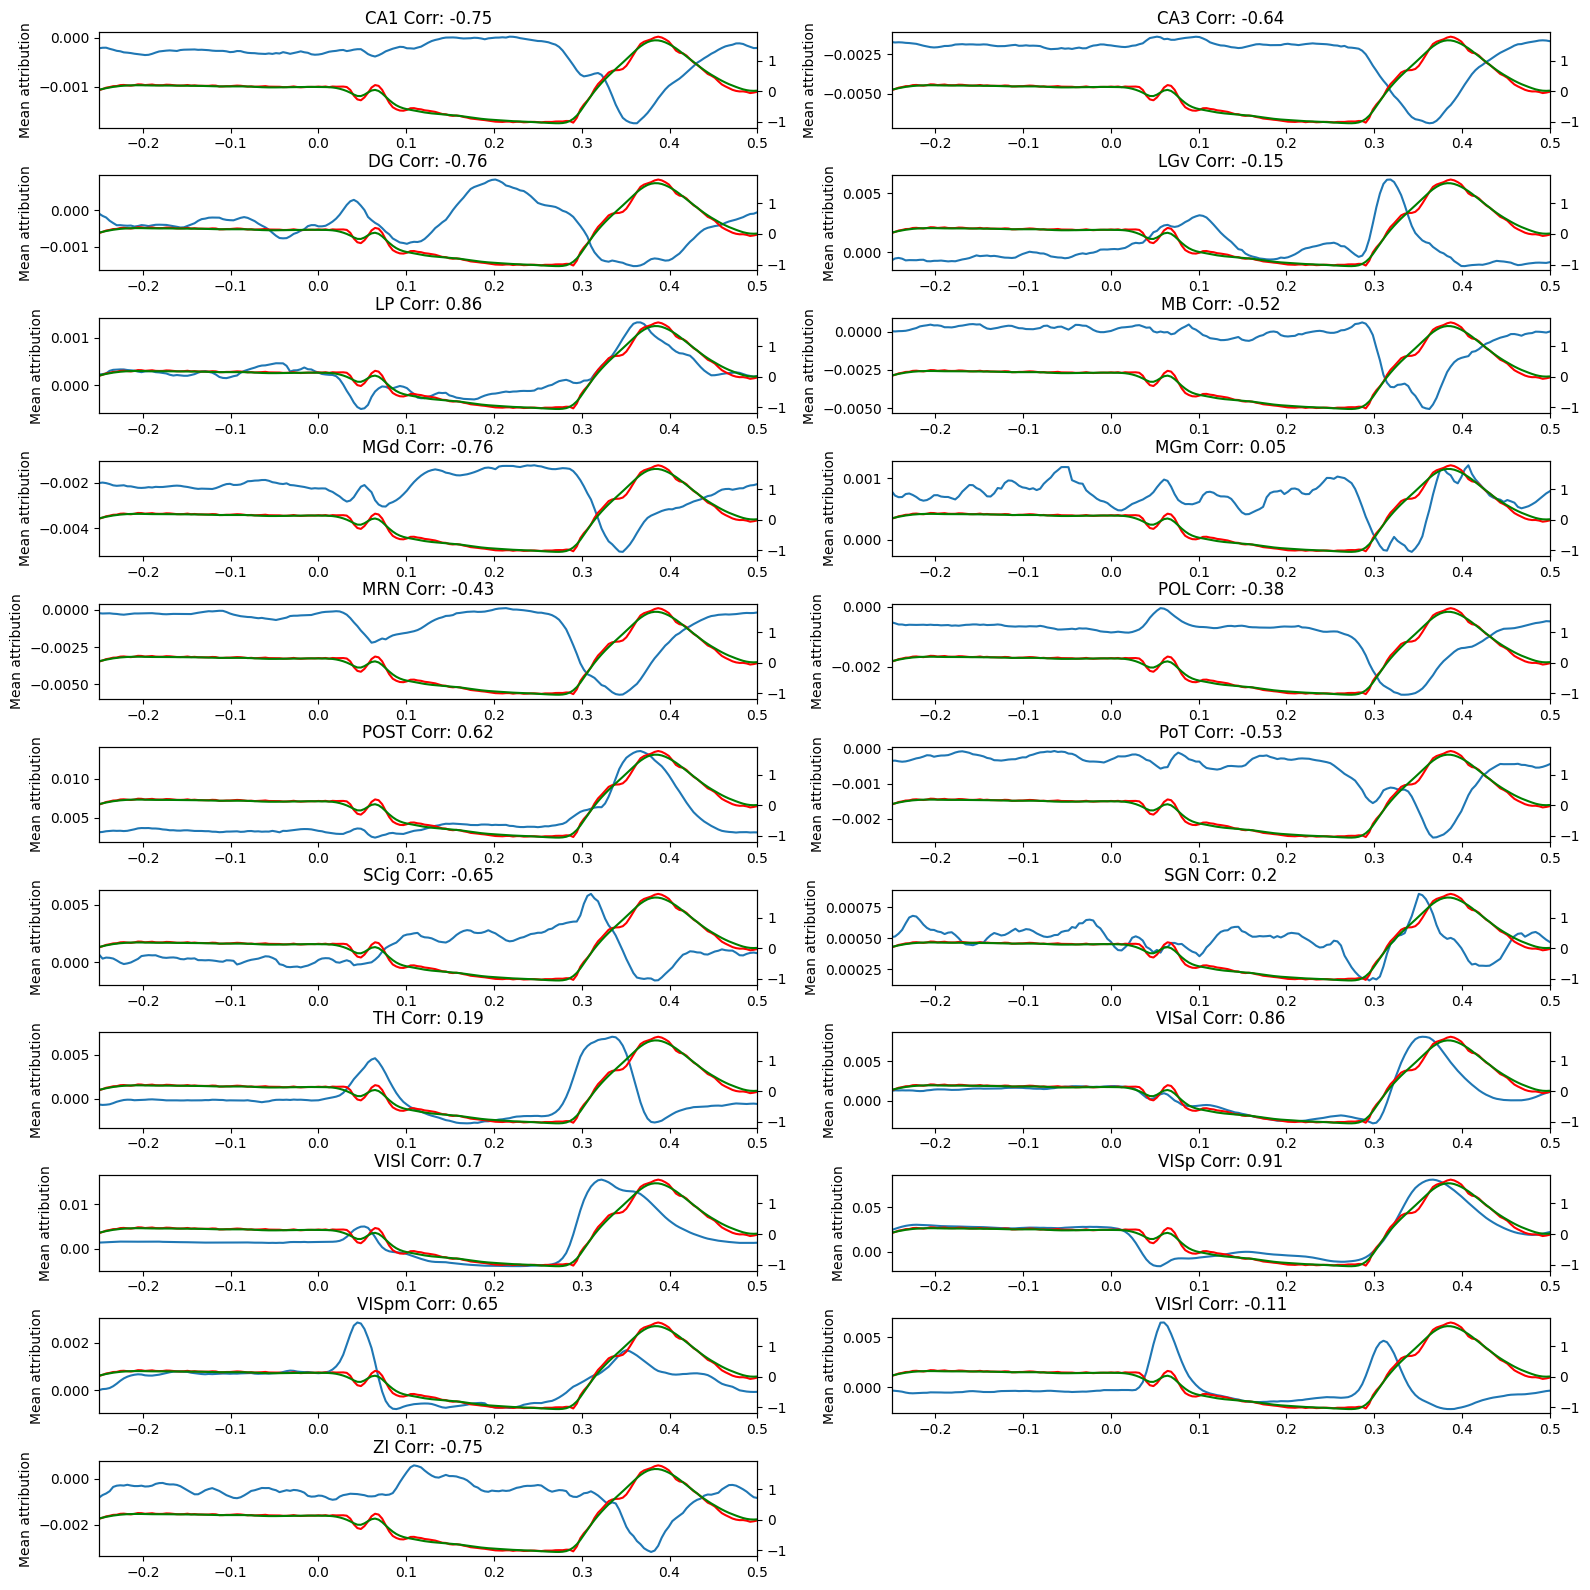

In [457]:
# for each area, plot the mean attributions of all units in that area
fig, ax = plt.subplots( int(np.ceil(len(areas)/2)) ,2,figsize=(16,16))

mean_lfp = np.mean(lfp_snippets, axis=0)
mean_yHat = np.mean(yHat_snippets, axis=0)

for areai in range(len(areas)):
    ind = locs == areas[areai]
    tmp = np.mean(attributions_snippets[:, :, ind], axis=2)
    ax.flat[areai].plot(t, np.mean(tmp, axis=0))
    # on the right y-axis, plot the mean LFP
    ax2 = ax.flat[areai].twinx()
    ax2.plot(t, mean_lfp, 'r')
    ax2.plot(t, mean_yHat, 'g')
    # ax.flat[areai].set_xlabel('Time (s)')
    ax.flat[areai].set_ylabel('Mean attribution')
    ax.flat[areai].set_xlim([-0.25, 0.5])
    # ax.flat[areai].set_ylim([-.03, 0.03])
    # add the correlation between the mean attribution and the mean LFP
    corr = np.corrcoef(mean_lfp, np.mean(tmp, axis=0))[0,1]
    ax.flat[areai].set_title(areas[areai] + ' Corr: ' + str(np.round(corr,2)))

# add space between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=.5)
ax.flat[-1].axis('off')

# note that the attribution of subcortical areas goes up after the stimulus while the attribution of cortical areas goes down

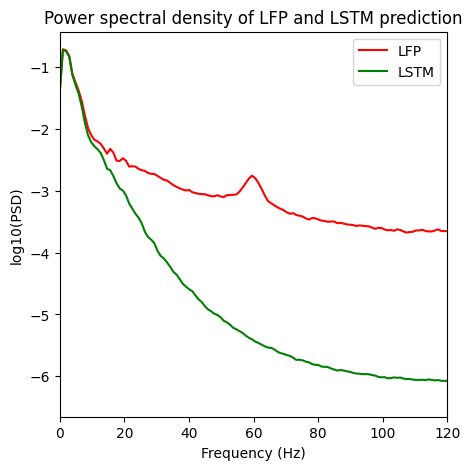

In [452]:
# compute the power spectral density of the LFP and the broadband model prediction
from scipy.signal import welch
f, Pxx = welch(data[:int(dur/bin_size),chani,0], 250, nperseg=256)
f, Pxx_hat = welch(yHat, 250, nperseg=256)

fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(f, np.log10(Pxx), 'r', label='LFP')
ax.plot(f, np.log10(Pxx_hat), 'g', label='LSTM')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log10(PSD)')
ax.set_title('Power spectral density of LFP and LSTM prediction')
ax.set_xlim([0, 120])
ax.legend()
plt.show()


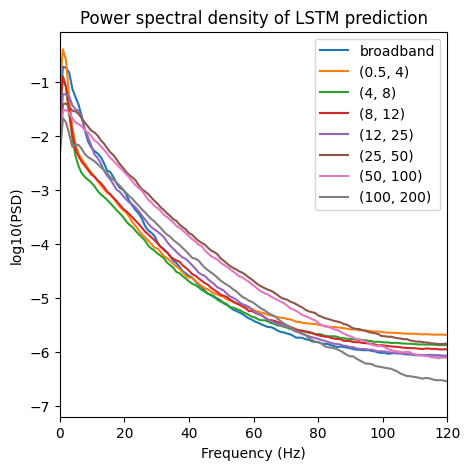

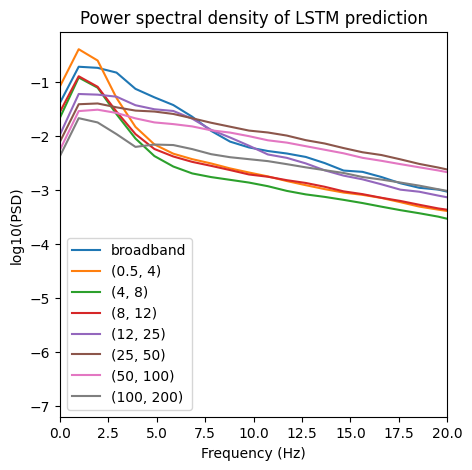

In [ ]:
# compute the power spectral density of each band of the LSTM prediction
Pxx_bands = np.zeros((len(bands)+1, len(f)))

for bandi in range(len(bands)+1):
    mdl = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion,'cpu')
    filename = output_dir / 'models' / str(session_id) / f'lstm_model_chan{chani}_band{bandi}.pt'
    mdl.model.load_state_dict(torch.load(filename))
    X_attr = spikes_obj.spkMat[:int(dur/bin_size), :] 
    X_attr_tensor = torch.tensor(X_attr, dtype=torch.float32)
    yHat = mdl.evaluate(X_attr_tensor)
    f, Pxx_bands[bandi,:] = welch(yHat, 250, nperseg=256)
    
fig, ax = plt.subplots(1,1,figsize=(5,5))
for bandi in range(len(bands)):
    ax.plot(f, np.log10(Pxx_bands[bandi,:]), label='broadband' if bandi == 0 else str(bands[bandi-1]))
    
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log10(PSD)')
ax.set_title('Power spectral density of LSTM prediction')
ax.set_xlim([0, 120])
ax.legend()
plt.show()


fig, ax = plt.subplots(1,1,figsize=(5,5))
for bandi in range(len(bands)):
    ax.plot(f, np.log10(Pxx_bands[bandi,:]), label='broadband' if bandi == 0 else str(bands[bandi-1]))
    
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log10(PSD)')
ax.set_title('Power spectral density of LSTM prediction')
ax.set_xlim([0, 20])
ax.legend()
plt.show()


### On another session

In [ ]:
session_id = 1044594870
session_obj = ss(session_id)
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

probe_obj = pp.probe(session_obj)
lfp_obj = ppd.pre_process_lfp(probe_obj.lfp, 1250)
lfp_obj.filter_lfp(probe_obj.bands)

c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  return func(args[0], **pargs)
100%|██████████| 778/778 [00:54<00:00, 14.40it/s]
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  return func(args[0], **pargs)
 12%|█▎        | 1/8 [00:20<02:26, 20.96s/it]

In [ ]:
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50
num_layers = 1
seqlength = 750
num_epochs = 1
X_train, y_train, X_test, y_test = ppd.generate_training_data(lfp_obj, spikes_obj, seqlength)

In [ ]:
# models, lossesAll_train = utils.train_models(probe_obj, input_size, hidden_size, num_layers, seqlength, device, num_epochs, X_train, y_train)
# save the models
output_dir = Path('F:/vbn_s3_cache')
# utils.save_models(models, output_dir, session_id)

100%|██████████| 19/19 [05:52<00:00, 18.54s/it]


In [ ]:
args = [input_size, hidden_size, num_layers, seqlength, device]
models = utils.load_models(output_dir, session_id, probe_obj, args)

In [14]:
output_dir = Path(r'F:\vbn_s3_cache')
dur = 720
bin_size = 0.004
pa.divide_task_for_attr(models, session_id, output_dir, spikes_obj, bin_size, probe_obj, dur)

PicklingError: Can't pickle <class 'lstm_module.LSTMnet'>: it's not the same object as lstm_module.LSTMnet